# Linear Regresion

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [5]:
#Import Points
df = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",")

In [6]:
df

,x,y
0,1,5
1,2,10
2,3,10
3,4,15
4,5,14
5,6,15
6,7,19
7,8,18
8,9,25
9,10,23


In [12]:
#Extract imputs variables
X = df.values[:, :-1]  #All rows, all columns but last column
#Extract output values
Y = df.values[:, -1] # all rows, las column

In [15]:
#fit a line to the point
fit = LinearRegression().fit(X, Y)

In [16]:
# m=1.78, b = -16.5
m = fit.coef_.flatten()
b = fit.intercept_.flatten()
print(f'm = {m}')
print(f'b = {b}')

m = [1.93939394]
b = [4.73333333]


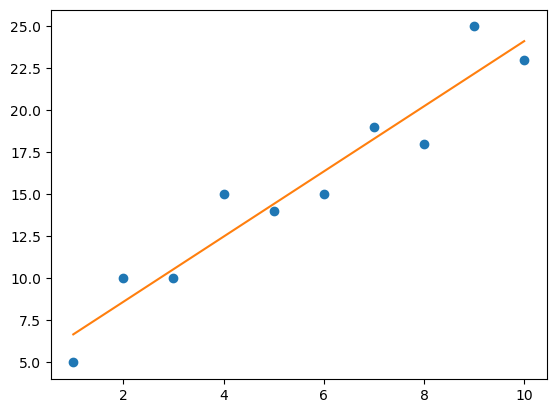

In [20]:
#show chart
plt.plot(X, Y, 'o') #Scatterplot
plt.plot(X, m*X+b) #Line
plt.show()

### Residuals and squared errors 

In [21]:
#best fit = we minimize the squares /the sum of the sauqred residuals

In [22]:
import pandas as pd

In [55]:
points = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",").itertuples()
points

In [53]:
#Test with a given line
m = 1.93939
b = 4.73333

In [54]:
#Calculate residuals
for p in points:
    y_actual = p.y
    y_predict = m * p.x+ b
    residual = y_actual - y_predict
    print(residual)

-1.67272
1.3878900000000005
-0.5515000000000008
2.5091099999999997
-0.4302799999999998
-1.3696699999999993
0.6909400000000012
-2.2484499999999983
2.812160000000002
-1.1272299999999973


In [ ]:
#Sumof squares for a given line and data 

In [51]:
points = pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",").itertuples()

#Test with a given line
m = 1.93939
b = 4.73333

sum_of_squares = 0.0

#Calculate sum of squares
for p in points:
    y_actual = p.y
    y_predict = m * p.x+ b
    residual_squares = (y_actual - y_predict)**2
    sum_of_squares += residual_squares
    
print(f'sum of squares = {sum_of_squares}')

sum of squares = 28.096969704500005


#### Finding the best fit Line 

In [56]:
#The sum ofsquares =the lower we can make that number, the better fit

In [57]:
#Calculating m and b for a simple linear regression 

In [64]:
points = list(pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",").itertuples())

n = len(points)

m = (n*sum(p.x*p.y for p in points) - sum(p.x for p in points) * sum(p.y for p in points)) / (n*sum(p.x**2 for p in points) - sum(p.x for p in points)**2)

b = (sum(p.y for p in points) / n) - m * sum(p.x for p in points) / n

print(m,b)

1.9393939393939394 4.7333333333333325


#### Inverse Matrix Technique 

In [65]:
#b = (X**T . X)**-1 . X**T . y

In [38]:
import pandas as pd
from numpy.linalg import inv
import numpy as np

points = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",")

X = points.values[:,:-1].flatten()
#Add placeholder 1 column to generate intercept
X_1 = np.vstack([X, np.ones(len(X))]).T
Y = points.values[:,-1]

#coeficients
b = inv(X_1.T @ X_1) @ (X_1.T @ Y)
print(b)

#Predict againt y-values
y_predict = X_1.dot(b)
y_predict

[1.93939394 4.73333333]


array([ 6.67272727,  8.61212121, 10.55151515, 12.49090909, 14.43030303,
       16.36969697, 18.30909091, 20.24848485, 22.18787879, 24.12727273])

In [1]:
import pandas as pd
from numpy.linalg import inv
import numpy as np

points = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",")

In [47]:
X = points.values[:,:-1].flatten()
Y = points.values[:,-1]
X1 = np.ones(len(X))

X2 = np.concatenate((X.reshape(-1,1), X1.reshape(-1,1)), axis=1)

B = inv(X2.T @ X2) @ (X2.T @ Y)
B

array([1.93939394, 4.73333333])

#### Matrix Decomposition 

In [48]:
# X = Q . R
# b = R**-1 . Q**T . y

In [50]:
import pandas as pd 
import numpy as np
from numpy.linalg import inv, qr

In [57]:
df = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",")

X = df.values[:,:-1].flatten() 
X1 = np.vstack([X, np.ones(len(X))]).T

Y = df.values[:,-1].flatten() 

#Using QR Decomposition
Q,R = qr(X1)
b = inv(R).dot(Q.transpose()).dot(Y)

print(b)

[1.93939394 4.73333333]


### Gradient Descent 

In [76]:
import random

def f(x):
    return (x - 3) ** 2 + 4

def dx_f(x):
    return 2 * (x - 3)

#The learning rate
L = 0.001

#The number of iterations to perform gradient decent
iterations = 100_000
#start ar rando x
x = random.randint(-15,15)


for i in range(iterations):
    #get slope
    d_x = dx_f(x)
    #update x by substracting the (learning rate) * (slope)
    x -= L * d_x
    #print(x)
    
print(x, f(x))

2.999999999999889 4.0


#### Gradient Decent for a Linear Regression

In [77]:
import pandas as pd 

points = list(pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",").itertuples())

In [87]:
#building the model
m = 0.0
b = 0.0

#Learning Rate and iterations
L = 0.001
iterations = 100_000

n = float(len(points)) #Numver of elements in X

#Perform gradient decent
for i in range(iterations):
    #slope with respect to m
    D_m = sum(2 * p.x * ((m * p.x + b) - p.y)for p in points)
    
    #slope with respect to b
    D_b = sum(2 * ((m * p.x + b) - p.y) for p in points)
    
    #update m and b
    m -= L * D_m
    b -= L * D_b
    
print(f'y = {m} x + {b}')

y = 1.9393939393939548 x + 4.733333333333227


In [82]:
#Using Sympy

from sympy import *

m, b, i, n = symbols('m b i n')
x, y = symbols('x y', cls=Function)
sum_of_squares = Sum((m * x(i) + b - y(i)) ** 2, (i, 0, n))

d_m = diff(sum_of_squares, m)
d_b = diff(sum_of_squares, b)

print(d_m)
print(d_b)

Sum(2*(b + m*x(i) - y(i))*x(i), (i, 0, n))
Sum(2*b + 2*m*x(i) - 2*y(i), (i, 0, n))


In [95]:
points = [(1,2), (2,4), (3,6)]
m = 1
b = 2

for x, y in points:
    error = (m*x + b) - y
    
    print(error)

1
0
-1


In [99]:
# Solving Linear Regression
import pandas as pd
from sympy import *

points = list(pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",").itertuples())

m, b, i, n = symbols('m b i n')
x, y = symbols('x y', cls=Function)

sum_of_squares = Sum((m * x(i) + b - y(i)) ** 2, (i, 0, n))

d_m = diff(sum_of_squares, m).subs(n, len(points) - 1).doit().replace(x, lambda i: points[i].x).replace(y, lambda i: points[i].y)
d_b = diff(sum_of_squares, b).subs(n, len(points) - 1).doit().replace(x, lambda i: points[i].x).replace(y, lambda i: points[i].y)

#Compile using lambdify for faster computation
d_m = lambdify([m, b], d_m)
d_b = lambdify([m, b], d_b)

#Building the model
m = 0.0
b = 0.0

#The leraning rate and iterations
L = 0.001
interations= 100_000

#Perform Gradient Decent
for i in range(iterations):
    #update m and b
    m -= d_m(m,b) * L
    b -= d_b(m,b) * L

print(f'y = {m} x + {b}')

y = 1.939393939393954 x + 4.733333333333231


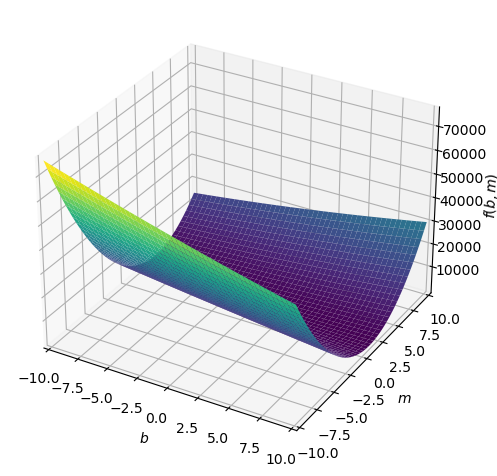

In [102]:
#Plotting the loss function 
from sympy import *
from sympy.plotting import plot3d
import pandas as pd

points = list(pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",").itertuples())

m, b, i, n = symbols('m b i n')
x, y = symbols('x y', cls=Function)

sum_of_squares = Sum((m * x(i) + b - y(i)) ** 2, (i, 0, n)).subs(n, len(points) - 1).doit().replace(x, lambda i: points[i].x).replace(y, lambda i: points[i].y)

plot3d(sum_of_squares)